In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
import statsmodels.formula.api as smf

# 1. 데이터 로드
df = pd.read_csv('marketing_clean_final.csv')

# 2. 클러스터링 준비
numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

# 3. K-Prototypes 클러스터링 (K=4, gamma=0.5)
kproto = KPrototypes(n_clusters=4, init='Cao', gamma=0.5, random_state=777, n_init=10, verbose=0)
df['Cluster'] = kproto.fit_predict(X_cluster, categorical=categorical_idx)

# 4. 세그먼트 이름 부여
segment_names = {
    2: 'VIP_Core_Customers',
    0: 'Senior_Stable_Customers',
    3: 'Low_Income_Young_Adults',
    1: 'Middle_Aged_MultiChild'
}
df['Segment_Name'] = df['Cluster'].map(segment_names)

print(df['Segment_Name'].value_counts())

Segment_Name
Low_Income_Young_Adults    617
Senior_Stable_Customers    574
VIP_Core_Customers         423
Middle_Aged_MultiChild     422
Name: count, dtype: int64


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

df = pd.read_csv('marketing_clean_final.csv')

# 1. 단순 상관계수 (이진변수 간 Pearson 상관계수 = phi coefficient와 동일)
corr = df[['AnyAccepted', 'Response']].corr().iloc[0, 1]
print(f'[1] Pearson 상관계수: {corr:.4f}')
print()

# 2. 분할표(contingency table) 확인
ct = pd.crosstab(df['AnyAccepted'], df['Response'], margins=True)
ct.index = ['AnyAccepted=0', 'AnyAccepted=1', '합계']
ct.columns = ['Response=0', 'Response=1', '합계']
print('[2] 분할표 (교차표)')
print(ct)
print()

# 캠페인 반응률 계산
rate_0 = ct_raw.loc[0, 1] / ct_raw.loc[0].sum() * 100
rate_1 = ct_raw.loc[1, 1] / ct_raw.loc[1].sum() * 100

print('[2-1] 그룹별 캠페인 반응률')
print(f'AnyAccepted=0 그룹 반응률: {rate_0:.2f}%  ({ct_raw.loc[0,1]}명 / {ct_raw.loc[0].sum()}명)')
print(f'AnyAccepted=1 그룹 반응률: {rate_1:.2f}%  ({ct_raw.loc[1,1]}명 / {ct_raw.loc[1].sum()}명)')
print(f'반응률 배율: {rate_1/rate_0:.2f}배')
print()

# 3. 카이제곱 검정
ct_raw = pd.crosstab(df['AnyAccepted'], df['Response'])
chi2, p_value, dof, expected = chi2_contingency(ct_raw)

print('[3] 카이제곱 독립성 검정')
print(f'chi2 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.8f}')
print(f'자유도: {dof}')
print(f'-> {"유의함 (연관 있음)" if p_value < 0.05 else "유의하지 않음 (독립적)"}  (유의수준 0.05 기준)')
print()

# 4. 오즈비 계산
a = ct_raw.loc[1, 1]  # AnyAccepted=1, Response=1
b = ct_raw.loc[1, 0]  # AnyAccepted=1, Response=0
c = ct_raw.loc[0, 1]  # AnyAccepted=0, Response=1
d = ct_raw.loc[0, 0]  # AnyAccepted=0, Response=0

odds_ratio = (a * d) / (b * c)
print('[4] 오즈비 (Odds Ratio)')
print(f'AnyAccepted=1 그룹 오즈: {a/b:.4f}')
print(f'AnyAccepted=0 그룹 오즈: {c/d:.4f}')
print(f'오즈비: {odds_ratio:.4f}')
print(f'-> AnyAccepted=1인 고객은 0인 고객보다 Response=1일 오즈가 {odds_ratio:.2f}배 높음')
print()

# 5. 로지스틱 회귀 (계수, p-value, 신뢰구간까지 한 번에)
model = smf.logit('Response ~ AnyAccepted', data=df).fit()
print()
print('[5] 로지스틱 회귀 결과')
print(model.summary())

print()
or_from_model = np.exp(model.params['AnyAccepted'])
ci = np.exp(model.conf_int().loc['AnyAccepted'])
print(f'오즈비 (로지스틱 회귀 기준): {or_from_model:.4f}')
print(f'95% 신뢰구간: [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'p-value: {model.pvalues["AnyAccepted"]:.6f}')

# 6. 그룹별 Response 비율 요약
print()
summary = df.groupby('AnyAccepted')['Response'].agg(['mean', 'count'])
summary.columns = ['Response 비율', '표본수']
summary['Response 비율'] = (summary['Response 비율'] * 100).round(2)
print('[6] 그룹별 Response 비율 요약')
print(summary)

[1] Pearson 상관계수: 0.3691

[2] 분할표 (교차표)
               Response=0  Response=1    합계
AnyAccepted=0        1475         138  1613
AnyAccepted=1         248         175   423
합계                   1723         313  2036



NameError: name 'ct_raw' is not defined

과거 캠페인 수락 경험은 이번 캠페인 반응 여부와 강하고 통계적으로 유의한 관계가 있다. 한 번이라도 캠페인에 반응했던 고객은, 그렇지 않은 고객보다 이번에도 반응할 가능성이 훨씬 높다 (반응률 기준 4.8배, 오즈 기준 7.5배). 이 결과는 여러 통계적 방법(카이제곱, 오즈비, 로지스틱 회귀)에서 일관되게 확인되어 신뢰도가 높다.

In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv('marketing_clean_final.csv')

# Recency를 추가한 통제 모델
model4 = smf.logit(
    'Response ~ AnyAccepted + Income + MntWines + Age + Children + C(Education) + C(Marital_Status) + Recency',
    data=df
).fit()

print(model4.summary())

# 오즈비 및 신뢰구간 정리
result4 = pd.DataFrame({
    'coef': model4.params,
    'p_value': model4.pvalues,
    'odds_ratio': np.exp(model4.params),
    'CI_lower': np.exp(model4.conf_int()[0]),
    'CI_upper': np.exp(model4.conf_int()[1])
}).round(4)

print(result4)

# Recency 추가 전(model3) vs 추가 후(model4) 비교
model3 = smf.logit(
    'Response ~ AnyAccepted + Income + MntWines + Age + Children + C(Education) + C(Marital_Status)',
    data=df
).fit(disp=0)

print('=== Recency 추가 전후 비교 ===')
print(f"model3 (Recency 없음) - AnyAccepted 오즈비: {np.exp(model3.params['AnyAccepted']):.4f}, Pseudo R²: {model3.prsquared:.4f}")
print(f"model4 (Recency 포함) - AnyAccepted 오즈비: {np.exp(model4.params['AnyAccepted']):.4f}, Pseudo R²: {model4.prsquared:.4f}")
print(f"Recency 오즈비: {np.exp(model4.params['Recency']):.4f}, p-value: {model4.pvalues['Recency']:.6f}")

Optimization terminated successfully.
         Current function value: 0.324069
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2022
Method:                           MLE   Df Model:                           13
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                  0.2448
Time:                        11:43:35   Log-Likelihood:                -659.80
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                 2.957e-83
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -1.2924      0.813     -1.590      0.

소득, 지출, 나이, 자녀 수, 학력, 결혼상태, 최근 구매 시점을 모두 통제해도 **과거 캠페인 참여 이력(오즈비 6.76)**과 **최근 구매일(Recency, 오즈비 0.975)**은 이번 캠페인 반응을 예측하는 가장 강력하고 독립적인 변수이며, 여기에 자녀 수가 적을수록, PhD 학력일수록, 미혼/이혼 상태일수록 반응 가능성이 유의하게 높아진다.

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_clean_final.csv')

# 클러스터링에 사용할 변수 (수치형 + 범주형)
numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

print("결측치 확인:")
print(df_cluster.isnull().sum())

# 수치형만 스케일링
scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])

# 범주형은 문자열로 유지 (K-Prototypes 요구사항)
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)
X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

print("X_cluster shape:", X_cluster.shape)
print("범주형 인덱스:", categorical_idx, categorical_cols)

결측치 확인:
Income            0
Age               0
Children          0
Education         0
Marital_Status    0
dtype: int64
X_cluster shape: (2036, 5)
범주형 인덱스: [3, 4] ['Education', 'Marital_Status']


k=2: cost=5279.51
k=3: cost=4223.01
k=4: cost=3446.13
k=5: cost=3103.23
k=6: cost=2840.05
k=7: cost=2663.92


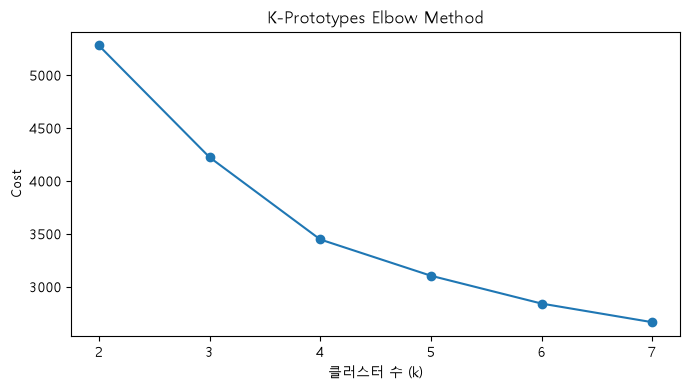

In [6]:
# 적정 k 탐색 (Cost 기반 Elbow Method)
costs = []
k_range = range(2, 8)

for k in k_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=777, n_init=5, verbose=0)
    kproto.fit_predict(X_cluster, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f'k={k}: cost={kproto.cost_:.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, costs, marker='o')
ax.set_xlabel('클러스터 수 (k)')
ax.set_ylabel('Cost')
ax.set_title('K-Prototypes Elbow Method')
plt.tight_layout()
plt.show()

k=2, cost=5279.51, silhouette=0.4169
k=3, cost=4222.98, silhouette=0.4318
k=4, cost=3446.13, silhouette=0.4633
k=5, cost=3103.23, silhouette=0.4429
k=6, cost=2840.02, silhouette=0.4159
k=7, cost=2663.73, silhouette=0.4164
k=8, cost=2505.96, silhouette=0.4195


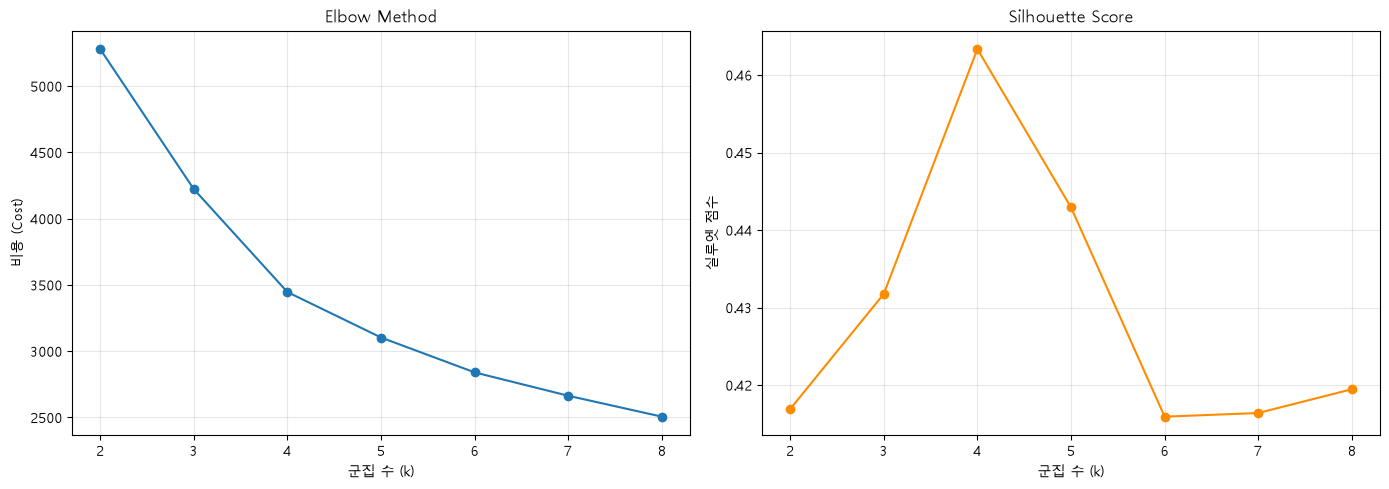

In [10]:
# Step 3-3. k 결정 - Elbow Method (k-prototypes), Silhouette Score (k-prototypes용 커스텀 거리 기반)
# Cost(비용) 값이 k가 증가함에 따라 급격히 줄다가 완만해지는 지점(elbow)을 찾음
# k-prototypes는 수치형(유클리드) + 범주형(매칭 거리)을 gamma로 합친 거리를 쓰기 때문에
# sklearn의 기본 silhouette_score를 바로 못 씀 -> 같은 방식으로 거리행렬을 직접 만들어서 precomputed로 계산

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols

df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_num_scaled = scaler.fit_transform(df_cluster[numeric_cols])
df_cat = df_cluster[categorical_cols].astype(str).values

categorical_idx = [3, 4]  # df_cluster_scaled 기준 Education, Marital_Status 위치
X_cluster = pd.concat(
    [pd.DataFrame(df_num_scaled, columns=numeric_cols), df_cluster[categorical_cols].astype(str)],
    axis=1
).values

# --- 혼합 거리행렬 계산 함수 ---
# 수치형: 유클리드 거리(제곱합) / 범주형: 다르면 1, 같으면 0 (매칭 거리) / gamma로 두 파트 결합
def mixed_distance_matrix(X_num, X_cat, gamma):
    num_dist = squareform(pdist(X_num, metric='euclidean')) ** 2
    n = X_cat.shape[0]
    cat_dist = np.zeros((n, n))
    for col in range(X_cat.shape[1]):
        col_vals = X_cat[:, col]
        mismatch = (col_vals[:, None] != col_vals[None, :]).astype(float)
        cat_dist += mismatch
    return num_dist + gamma * cat_dist

k_range = range(2, 9)
costs = []
sil_scores = []

for k in k_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=42, verbose=0)
    labels = kproto.fit_predict(X_cluster, categorical=categorical_idx)
    costs.append(kproto.cost_)

    dist_matrix = mixed_distance_matrix(df_num_scaled, df_cat, gamma=kproto.gamma)
    sil = silhouette_score(dist_matrix, labels, metric='precomputed')
    sil_scores.append(sil)

    print(f"k={k}, cost={kproto.cost_:.2f}, silhouette={sil:.4f}")

# --- 시각화: Elbow + Silhouette 나란히 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), costs, marker='o')
axes[0].set_xlabel("군집 수 (k)")
axes[0].set_ylabel("비용 (Cost)")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel("군집 수 (k)")
axes[1].set_ylabel("실루엣 점수")
axes[1].set_title("Silhouette Score")
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_clean_final.csv')

numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

# 실루엣 계산용 근사 벡터: 범주형은 One-Hot으로 별도 변환해서 수치형과 이어붙임
# (주의: K-Prototypes 자체의 혼합거리와 완전히 동일하진 않은 "근사치"입니다)
cat_dummies = pd.get_dummies(df_cluster[categorical_cols].astype(str)).astype(float)
X_for_sil = np.hstack([df_cluster_scaled[numeric_cols].values, cat_dummies.values])

In [11]:
kproto = KPrototypes(n_clusters=4, init='Cao', random_state=777, n_init=10, verbose=0)
labels = kproto.fit_predict(X_cluster, categorical=categorical_idx)
df['Cluster'] = labels

print('Cost:', kproto.cost_)
print(df['Cluster'].value_counts().sort_index())

cluster_profile = df.groupby('Cluster').agg(
    count=('ID', 'count'),
    Income_avg=('Income', 'mean'),
    Age_avg=('Age', 'mean'),
    Children_avg=('Children', 'mean'),
    AnyAccepted_rate=('AnyAccepted', 'mean'),
    Response_rate=('Response', 'mean')
).round(2)

print(cluster_profile)

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    print(f'--- Cluster {c} (n={len(sub)}) ---')
    print('Education 분포:', sub['Education'].value_counts(normalize=True).round(2).to_dict())
    print('Marital_Status 분포:', sub['Marital_Status'].value_counts(normalize=True).round(2).to_dict())
    print()

Cost: 3446.128998911126
Cluster
0    574
1    422
2    423
3    617
Name: count, dtype: int64
         count  Income_avg  Age_avg  Children_avg  AnyAccepted_rate  \
Cluster                                                               
0          574    62420.87    57.57          0.59              0.26   
1          422    45255.41    48.90          2.11              0.11   
2          423    74021.85    37.23          0.39              0.38   
3          617    31948.56    36.38          0.88              0.10   

         Response_rate  
Cluster                 
0                 0.16  
1                 0.11  
2                 0.24  
3                 0.12  
--- Cluster 0 (n=574) ---
Education 분포: {'Graduation': 0.5, 'Master': 0.25, 'PhD': 0.24, 'Basic': 0.01}
Marital_Status 분포: {'Married': 0.36, 'Together': 0.25, 'Single': 0.19, 'Divorced': 0.13, 'Widow': 0.07}

--- Cluster 1 (n=422) ---
Education 분포: {'Graduation': 0.48, 'Master': 0.26, 'PhD': 0.25, 'Basic': 0.0}
Marital_Status 분

PC1+PC2 설명분산: 56.3%


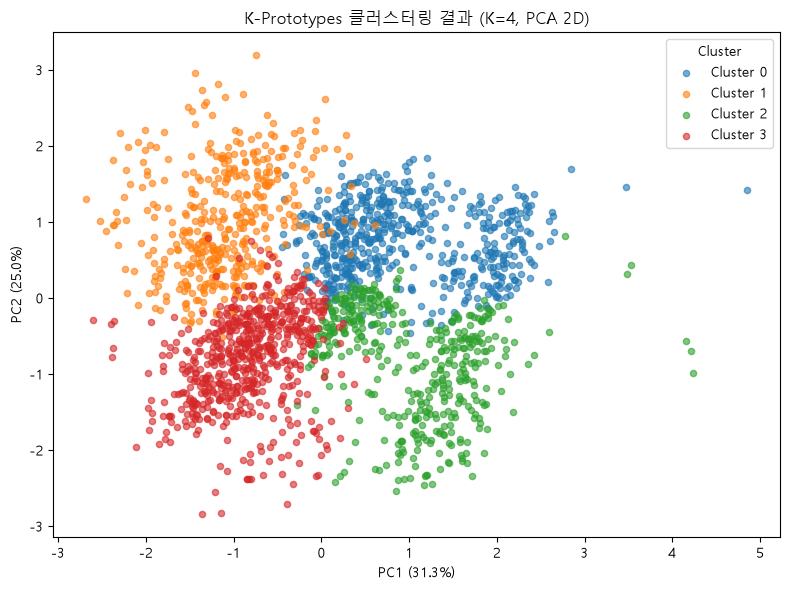

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 시각화를 위해 수치형(스케일링됨) + 범주형(One-Hot) 벡터로 PCA 수행
cat_dummies_full = pd.get_dummies(df[categorical_cols].astype(str)).astype(float)
X_for_viz = np.hstack([df_cluster_scaled[numeric_cols].values, cat_dummies_full.values])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_for_viz)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f'PC1+PC2 설명분산: {sum(pca.explained_variance_ratio_)*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red'}

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], c=colors[c], label=f'Cluster {c}', alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Prototypes 클러스터링 결과 (K=4, PCA 2D)')
ax.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

df = pd.read_csv('marketing_clean_final.csv')
numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

# 감마 1, 2, 3 각각 비교
for gamma in [1.0, 2.0, 3.0]:
    print(f'===== gamma={gamma} =====')
    kproto = KPrototypes(n_clusters=4, init='Cao', gamma=gamma, random_state=777, n_init=10, verbose=0)
    labels = kproto.fit_predict(X_cluster, categorical=categorical_idx)
    df['Cluster'] = labels
    print('Cost:', round(kproto.cost_, 2))

    profile = df.groupby('Cluster').agg(
        count=('ID', 'count'),
        Income_avg=('Income', 'mean'),
        Age_avg=('Age', 'mean'),
        Children_avg=('Children', 'mean'),
        Response_rate=('Response', 'mean')
    ).round(2)
    print(profile)

    for c in sorted(df['Cluster'].unique()):
        sub = df[df['Cluster'] == c]
        edu = sub['Education'].value_counts(normalize=True).round(2).to_dict()
        mar = sub['Marital_Status'].value_counts(normalize=True).round(2).to_dict()
        print(f'  Cluster {c}: Education={edu}')
        print(f'              Marital={mar}')
    print()

===== gamma=1.0 =====
Cost: 4575.63
         count  Income_avg  Age_avg  Children_avg  Response_rate
Cluster                                                         
0          574    62420.87    57.57          0.59           0.16
1          422    45255.41    48.90          2.11           0.11
2          423    74021.85    37.23          0.39           0.24
3          617    31948.56    36.38          0.88           0.12
  Cluster 0: Education={'Graduation': 0.5, 'Master': 0.25, 'PhD': 0.24, 'Basic': 0.01}
              Marital={'Married': 0.36, 'Together': 0.25, 'Single': 0.19, 'Divorced': 0.13, 'Widow': 0.07}
  Cluster 1: Education={'Graduation': 0.48, 'Master': 0.26, 'PhD': 0.25, 'Basic': 0.0}
              Marital={'Married': 0.4, 'Together': 0.27, 'Single': 0.18, 'Divorced': 0.12, 'Widow': 0.03}
  Cluster 2: Education={'Graduation': 0.54, 'Master': 0.23, 'PhD': 0.23}
              Marital={'Married': 0.39, 'Together': 0.26, 'Single': 0.24, 'Divorced': 0.1, 'Widow': 0.02}
  Cluste

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes

df = pd.read_csv('marketing_clean_final.csv')
numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

# gamma와 무관하게 "공정하게" 비교하기 위한 고정 평가 벡터
# (수치형 스케일링 + 범주형 One-Hot을 그대로 이어붙여서, gamma 설정과 상관없이 항상 동일한 기준으로 평가)
cat_dummies = pd.get_dummies(df_cluster[categorical_cols].astype(str)).astype(float)
X_for_sil = np.hstack([df_cluster_scaled[numeric_cols].values, cat_dummies.values])

gammas = [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
for gamma in gammas:
    kproto = KPrototypes(n_clusters=4, init='Cao', gamma=gamma, random_state=777, n_init=10, verbose=0)
    labels = kproto.fit_predict(X_cluster, categorical=categorical_idx)
    sil = silhouette_score(X_for_sil, labels)
    print(f'gamma={gamma}: silhouette(고정기준)={sil:.4f}, cost={kproto.cost_:.1f}')

gamma=0.25: silhouette(고정기준)=0.2034, cost=2881.4
gamma=0.5: silhouette(고정기준)=0.2034, cost=3446.1
gamma=1.0: silhouette(고정기준)=0.2034, cost=4575.6
gamma=1.5: silhouette(고정기준)=0.1962, cost=5719.3
gamma=2.0: silhouette(고정기준)=0.1636, cost=6807.1
gamma=2.5: silhouette(고정기준)=0.1484, cost=7718.3
gamma=3.0: silhouette(고정기준)=0.1202, cost=8641.9
gamma=4.0: silhouette(고정기준)=0.1012, cost=9956.2
gamma=5.0: silhouette(고정기준)=0.0811, cost=11144.3


In [11]:
# [셀 1] 먼저 실행 — 클러스터링 + 세그먼트 이름 부여
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
import statsmodels.formula.api as smf

df = pd.read_csv('marketing_clean_final.csv')

numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

kproto = KPrototypes(n_clusters=4, init='Cao', gamma=0.5, random_state=777, n_init=10, verbose=0)
df['Cluster'] = kproto.fit_predict(X_cluster, categorical=categorical_idx)

segment_names = {
    2: 'VIP_Core_Customers',
    0: 'Senior_Stable_Customers',
    3: 'Low_Income_Young_Adults',
    1: 'Middle_Aged_MultiChild'
}
df['Segment_Name'] = df['Cluster'].map(segment_names)

print('Segment_Name 컬럼 생성 확인:', 'Segment_Name' in df.columns)
print(df['Segment_Name'].value_counts())

Segment_Name 컬럼 생성 확인: True
Segment_Name
Low_Income_Young_Adults    617
Senior_Stable_Customers    574
VIP_Core_Customers         423
Middle_Aged_MultiChild     422
Name: count, dtype: int64


In [12]:
# [셀 2] 그 다음 실행 — 로지스틱 회귀
results = []
for seg in df['Segment_Name'].unique():
    sub = df[df['Segment_Name'] == seg]
    model = smf.logit('Response ~ AnyAccepted', data=sub).fit(disp=0)

    or_val = np.exp(model.params['AnyAccepted'])
    p_val = model.pvalues['AnyAccepted']
    ci = np.exp(model.conf_int().loc['AnyAccepted'])

    results.append({
        'Segment': seg,
        'n': len(sub),
        'OddsRatio': round(or_val, 2),
        'p_value': round(p_val, 5),
        'CI_lower': round(ci[0], 2),
        'CI_upper': round(ci[1], 2),
        'PseudoR2': round(model.prsquared, 4)
    })

result_df = pd.DataFrame(results)
print(result_df)

                   Segment    n  OddsRatio  p_value  CI_lower  CI_upper  \
0   Middle_Aged_MultiChild  422       4.70  0.00003      2.28      9.71   
1  Low_Income_Young_Adults  617       9.35  0.00000      5.24     16.69   
2       VIP_Core_Customers  423       8.32  0.00000      5.00     13.85   
3  Senior_Stable_Customers  574       6.27  0.00000      3.88     10.12   

   PseudoR2  
0    0.0526  
1    0.1159  
2    0.1645  
3    0.1170  


In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# 데이터 로드
df = pd.read_csv('marketing_clean_final.csv')

# 클러스터링에 사용할 변수 준비
numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

# 수치형만 스케일링
scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])

# 범주형은 문자열로 유지 (K-Prototypes 요구사항)
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)
X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

# K-Prototypes 클러스터링 (K=4, gamma=0.5)
kproto = KPrototypes(n_clusters=4, init='Cao', gamma=0.5, random_state=777, n_init=10, verbose=0)
df['Cluster'] = kproto.fit_predict(X_cluster, categorical=categorical_idx)  

# 세그먼트 이름 및 우선순위(Response율 기준) 매핑
segment_info = {
    2: ('VIP_Core_Customers', 1),        # Response 24.35% - 1순위
    0: ('Senior_Stable_Customers', 2),   # Response 15.68% - 2순위
    3: ('Low_Income_Young_Adults', 3),   # Response 11.99% - 3순위
    1: ('Middle_Aged_MultiChild', 4),    # Response 10.90% - 4순위
}

df['Segment_Name'] = df['Cluster'].map(lambda x: segment_info[x][0])
df['Segment_Priority'] = df['Cluster'].map(lambda x: segment_info[x][1])

# 확인
summary = df.groupby(['Segment_Priority', 'Segment_Name']).agg(
    count=('ID', 'count'),
    Response_rate=('Response', 'mean')
).round(4)
print(summary)

# CSV로 저장
df.to_csv('marketing_segmented.csv', index=False)
print('저장 완료')

                                          count  Response_rate
Segment_Priority Segment_Name                                 
1                VIP_Core_Customers         423         0.2435
2                Senior_Stable_Customers    574         0.1568
3                Low_Income_Young_Adults    617         0.1199
4                Middle_Aged_MultiChild     422         0.1090
저장 완료
